In [1]:
!pwd

/home/Mukharyam/audio-llm-yandex-camp-1/notebooks


In [2]:
import sys
import os
from pathlib import Path

# Автопоиск корня проекта по маркерам
current_path = Path(os.getcwd())
for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists() and (parent / "notebooks").exists():
        project_root = parent
        break
else:
    project_root = current_path  # fallback

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Using project root: {project_root}")

Using project root: /home/Mukharyam/audio-llm-yandex-camp-1


In [3]:
from typing import Any

import torch
import matplotlib.pyplot as plt
import numpy as np
import IPython.display
from tqdm.auto import tqdm
from termcolor import colored

from src.asr_eval.align.data import MatchesList
from src.datasets_list import load_podlodka
from src.asr_eval.utils.types import FLOATS
from src.asr_eval.models.whisper_wrapper import WhisperLongformWrapper
from src.asr_eval.align.parsing import parse_multivariant_string, split_text_into_tokens
from src.asr_eval.align.recursive import align
from src.asr_eval.utils.formatting import Formatting, FormattingSpan, apply_ansi_formatting

print(f'{torch.cuda.is_available() = }')  # True for GPU server, False for CPU server

torch.cuda.is_available() = True


In [4]:
# load the dataset

dataset = load_podlodka()
dataset

Dataset({
    features: ['audio', 'transcription', 'episode', 'title'],
    num_rows: 20
})

In [5]:
# take a sample

sample: dict[str, Any] = dataset[0]
display(sample)

{'audio': {'path': 'sound_test_0001.wav',
  'array': array([-0.00219727, -0.00457764, -0.00421143, ...,  0.00085449,
          0.00036621,  0.0005188 ], shape=(129938,)),
  'sampling_rate': 16000},
 'transcription': 'И поэтому использовать их в повседневности не получается. Мы вынуждены поступать зачастую интуитивно.',
 'episode': 132,
 'title': 'Дисфункции организаций'}

In [6]:
# audio is 1D array (16K elements = 1 sec)

waveform: FLOATS = sample['audio']['array']
print(f'{waveform.shape = }')

sampling_rate: int = sample['audio']['sampling_rate']
print(f'{sampling_rate = }')

waveform.shape = (129938,)
sampling_rate = 16000


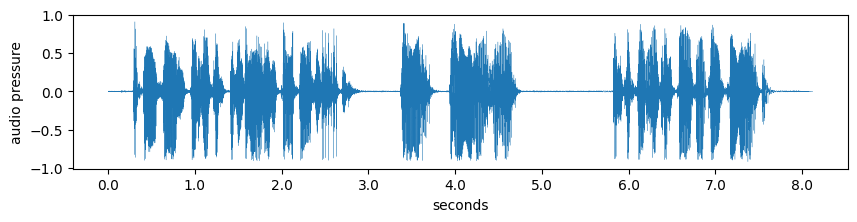

In [7]:
# plot a waveform

# type: ignore

plt.figure(figsize=(10, 2))
plt.plot(waveform, lw=0.2)

# draw tick labels
audio_len_seconds = len(waveform) / sampling_rate
xticks = np.arange(0, audio_len_seconds)
plt.gca().set_xticks(xticks * sampling_rate)
plt.gca().set_xticklabels(xticks)

plt.xlabel('seconds')
plt.ylabel('audio pressure')

plt.show()

In [8]:
# show widget to play the audio
IPython.display.Audio(waveform, rate=sample['audio']['sampling_rate'])

In [9]:
# load a model

model = WhisperLongformWrapper('openai/whisper-tiny') # tiny model for CPU inference

In [10]:
# model prediction

prediction = model([waveform])[0]
prediction

Device set to use cuda:0


' И поэтому используйте их в последнейности не получается. Мы вынуждены поступать за чувствую интуитивано.'

In [11]:
# true words from the dataset annotation
# `parse_multivariant_string` is the same as `split_text_into_tokens`,
# but support multivariant annotations like "{one|1} {dollar|$}"

true_words = parse_multivariant_string(sample['transcription'])
true_words

[Token(и),
 Token(поэтому),
 Token(использовать),
 Token(их),
 Token(в),
 Token(повседневности),
 Token(не),
 Token(получается),
 Token(мы),
 Token(вынуждены),
 Token(поступать),
 Token(зачастую),
 Token(интуитивно)]

In [12]:
# align true with pred to find errors
alignment = align(true_words, split_text_into_tokens(prediction))

display(alignment.matches)
print(f'{alignment.score.n_word_errors = }') # get n errors

[Match(и, и),
 Match(поэтому, поэтому),
 Match(использовать, используйте),
 Match(их, их),
 Match(в, в),
 Match(повседневности, последнейности),
 Match(не, не),
 Match(получается, получается),
 Match(мы, мы),
 Match(вынуждены, вынуждены),
 Match(поступать, поступать),
 Match(, за),
 Match(зачастую, чувствую),
 Match(интуитивно, интуитивано)]

alignment.score.n_word_errors = 5


In [13]:
# WER = n_errors / n_true_words
# for multivariant labeling, n_true_words may be ambiguous
# for single-variant labeling, it is straightforward to calculate

wer = alignment.score.n_word_errors / len(true_words)
print(f'{wer = :.2f}')

wer = 0.38


In [14]:
# display in color

def display_alignment(alignment: MatchesList):
    true_line: str = 'TRUE: '
    pred_line: str = 'PRED: '
    color_spans: list[FormattingSpan] = []

    for m in alignment.matches:
        true_word = str(m.true.value) if m.true is not None else ''
        pred_word = str(m.pred.value) if m.pred is not None else ''
        
        display_length = max(len(true_word), len(pred_word))
        true_word = true_word.ljust(display_length)
        pred_word = pred_word.ljust(display_length)
        
        pred_span = (len(pred_line), len(pred_line) + len(pred_word))
        
        true_line += true_word + ' '
        pred_line += pred_word + ' '
        
        match m.status:
            case 'correct':
                pass
            case 'replacement' | 'deletion' | 'insertion':
                color_spans.append(FormattingSpan(Formatting(on_color='on_yellow'), *pred_span))
        
    print(colored(true_line, attrs=['bold']))
    print(apply_ansi_formatting(pred_line, color_spans))

display_alignment(alignment)

TRUE: и поэтому использовать их в повседневности не получается мы вынуждены поступать    зачастую интуитивно  
PRED: и поэтому используйте  их в последнейности не получается мы вынуждены поступать за чувствую интуитивано 


In [15]:
# get prediction and WER for 10 dataset samples

preds: list[str] = []
alignments: list[MatchesList] = []

for sample in tqdm(dataset.take(10)): # type: ignore
    assert sample['audio']['sampling_rate'] == 16_000 # type: ignore
    
    preds.append(prediction := model([sample['audio']['array']])[0]) # type: ignore
    
    alignments.append(alignment := align(
        parse_multivariant_string(sample['transcription']), # type: ignore
        split_text_into_tokens(prediction),
    ))
    
    display_alignment(alignment)

  0%|          | 0/10 [00:00<?, ?it/s]

TRUE: и поэтому использовать их в повседневности не получается мы вынуждены поступать    зачастую интуитивно  
PRED: и поэтому используйте  их в последнейности не получается мы вынуждены поступать за чувствую интуитивано 
TRUE: максимально ухудшить идеальную систему вводя    туда какие то элементы или условия чтобы итоговая результат должен быть такой мы должны в 22 раза замедлить нашу разработку 
PRED: максимально ухудшить идеальную систему вводи от туда какие то элементы или условия чтобы итоговая результат должен быть такой мы должны в 22 раза замедлить нашу разработку 
TRUE: человек недавно ставший   тимлидом и который сказал знаешь заходит в чатик и говорит ребята меня вчера сделали тимлидом с чего мне начать и ему там дают ссылку что в  первые девяносто   дней ты должен и дальше там по порядку one   on  one     performance review там пятое десятое очень легко натащить этого всего 
PRED: человек недавно ставший в темлидом и который сказал знаешь какой     четый   год     ребята ме

In [16]:
wers = [
    al.score.n_word_errors / al.total_true_len
    if al.total_true_len > 0 else 1
    for al in alignments
]
print(f'average WER = {np.mean(wers):.2f}')

average WER = 0.32


In [17]:
# an example with multivariant labeling

true_words = parse_multivariant_string('<*> {one|1} {2|two|twooo} qq <*> ww {zz}')
display(true_words)

alignment = align(
    true_words,
    split_text_into_tokens('one two qqq a b c ww ww zz'),
)
display(alignment.matches)

f'{alignment.score.n_word_errors = }'

[Token(Anything()),
 MultiVariant([Token(one)], [Token(1)]),
 MultiVariant([Token(2)], [Token(two)], [Token(twooo)]),
 Token(qq),
 Token(Anything()),
 Token(ww),
 MultiVariant([Token(zz)], [])]

[Match(Anything(), ),
 Match(one, one),
 Match(two, two),
 Match(qq, qqq),
 Match(Anything(), a),
 Match(Anything(), b),
 Match(Anything(), c),
 Match(Anything(), ww),
 Match(ww, ww),
 Match(zz, zz)]

'alignment.score.n_word_errors = 1'